# Human Development Index (HDI) Predictor
### ML - 0027 - Model Training Notebook

This notebook covers the full ML lifecycle for the HDI Predictor project:
1. Import Libraries
2. Load & Understand the Dataset
3. Exploratory Data Analysis (EDA)
4. Data Preprocessing & Label Encoding
5. Train / Test Split
6. Model Training (Linear Regression)
7. Model Evaluation
8. Saving the Model (Pickle)


## Epic 2: Importing Required Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import pickle

sns.set_style("darkgrid")
%matplotlib inline


## Epic 3: Dataset Download & Understanding

The dataset (`HDI.csv`) contains country-level indicators used to estimate the
Human Development Index:

- **Country** - name of the country
- **Life_Expectancy** - average life expectancy at birth (years)
- **Mean_Years_Schooling** - average years of schooling for adults
- **GNI_Per_Capita** - Gross National Income per capita (USD, PPP)
- **Internet_Users** - percentage of the population using the internet
- **HDI** - Human Development Index score (target variable, 0-1)
- **HDI_Category** - Low / Medium / High / Very High classification of HDI


In [2]:
df = pd.read_csv("../Dataset/HDI.csv")
print(df.shape)
df.head()


(120, 7)


,Country,Life_Expectancy,Mean_Years_Schooling,GNI_Per_Capita,Internet_Users,HDI,HDI_Category
0,Mali,46.8,3.4,1532.0,22.3,0.320,Low
1,Dominican Republic,72.9,10.7,22642.0,83.0,0.760,High
2,Fiji,72.5,8.6,22554.0,60.8,0.652,Medium
3,Zimbabwe,48.4,4.4,421.0,24.3,0.306,Low
4,Kenya,67.5,5.6,4960.0,23.0,0.451,Low


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Country               120 non-null    str    
 1   Life_Expectancy       116 non-null    float64
 2   Mean_Years_Schooling  116 non-null    float64
 3   GNI_Per_Capita        116 non-null    float64
 4   Internet_Users        116 non-null    float64
 5   HDI                   120 non-null    float64
 6   HDI_Category          120 non-null    str    
dtypes: float64(5), str(2)
memory usage: 6.7 KB


In [4]:
df.describe()


,Life_Expectancy,Mean_Years_Schooling,GNI_Per_Capita,Internet_Users,HDI
count,116.000000,116.000000,116.000000,116.000000,120.000000
mean,68.144828,8.044828,25951.939655,54.375000,0.609950
std,11.788700,3.822641,33646.938615,31.075702,0.235681
min,45.200000,1.100000,421.000000,3.200000,0.194000
25%,58.525000,4.475000,2166.500000,23.150000,0.375750
50%,70.250000,8.450000,9762.000000,57.650000,0.611500
75%,78.275000,11.200000,31512.250000,86.525000,0.829000
max,84.600000,14.500000,127110.000000,98.600000,0.966000


In [5]:
df['HDI_Category'].value_counts()


HDI_Category
Low          53
Very High    31
High         25
Medium       11
Name: count, dtype: int64

## Data Visualization & EDA

/tmp/ipykernel_600/2461388099.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(x='HDI_Category', y='HDI', data=df,


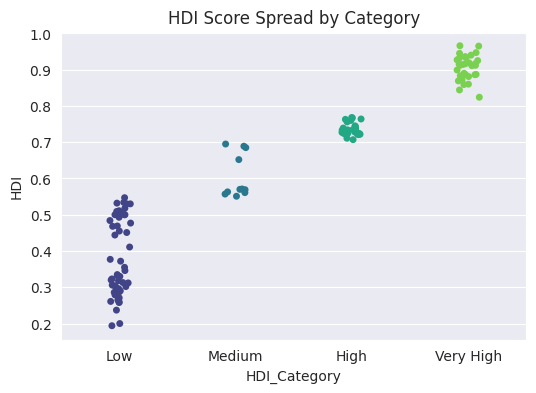

In [6]:
plt.figure(figsize=(6,4))
sns.stripplot(x='HDI_Category', y='HDI', data=df,
              order=['Low','Medium','High','Very High'], palette='viridis')
plt.title('HDI Score Spread by Category')
plt.show()


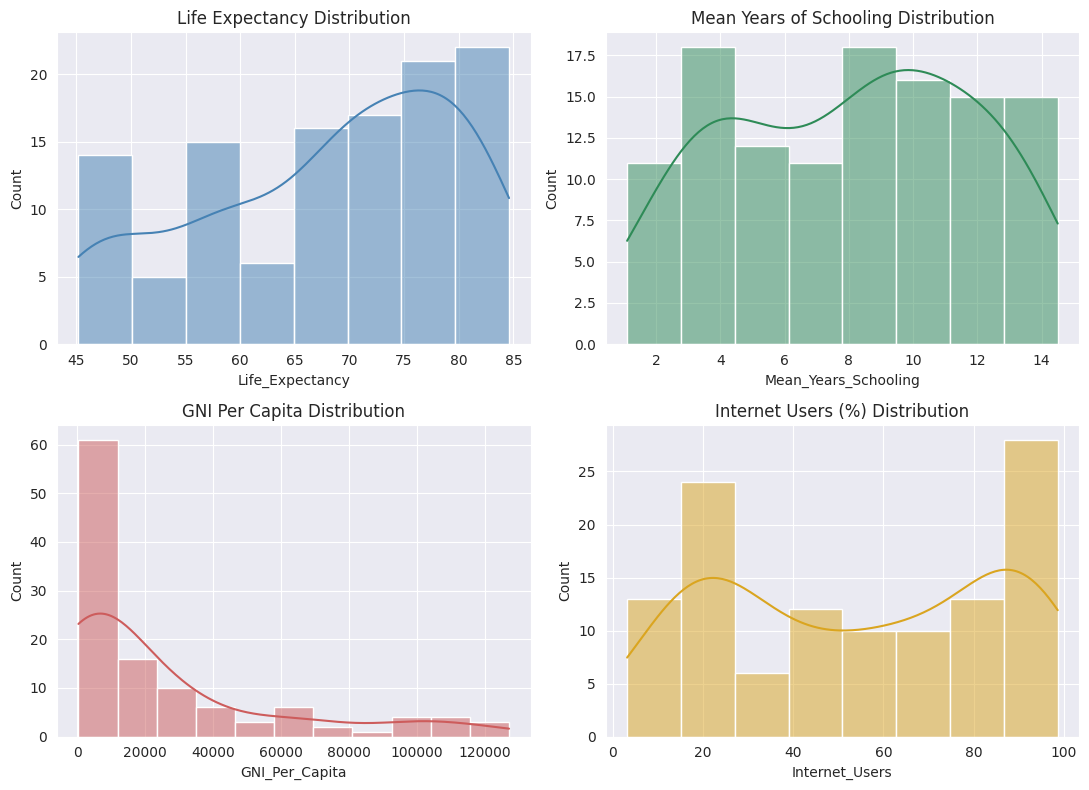

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
sns.histplot(df['Life_Expectancy'].dropna(), kde=True, ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Life Expectancy Distribution')
sns.histplot(df['Mean_Years_Schooling'].dropna(), kde=True, ax=axes[0,1], color='seagreen')
axes[0,1].set_title('Mean Years of Schooling Distribution')
sns.histplot(df['GNI_Per_Capita'].dropna(), kde=True, ax=axes[1,0], color='indianred')
axes[1,0].set_title('GNI Per Capita Distribution')
sns.histplot(df['Internet_Users'].dropna(), kde=True, ax=axes[1,1], color='goldenrod')
axes[1,1].set_title('Internet Users (%) Distribution')
plt.tight_layout()
plt.show()


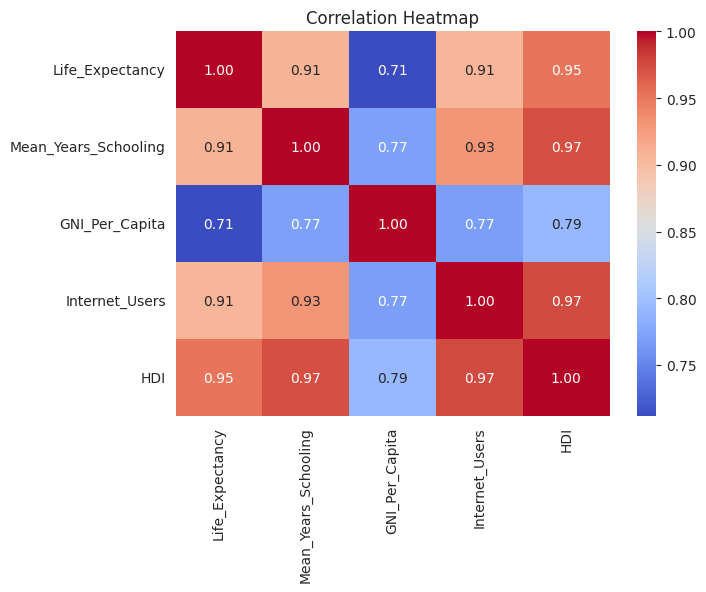

In [8]:
plt.figure(figsize=(7,5))
numeric_cols = ['Life_Expectancy','Mean_Years_Schooling','GNI_Per_Capita','Internet_Users','HDI']
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()


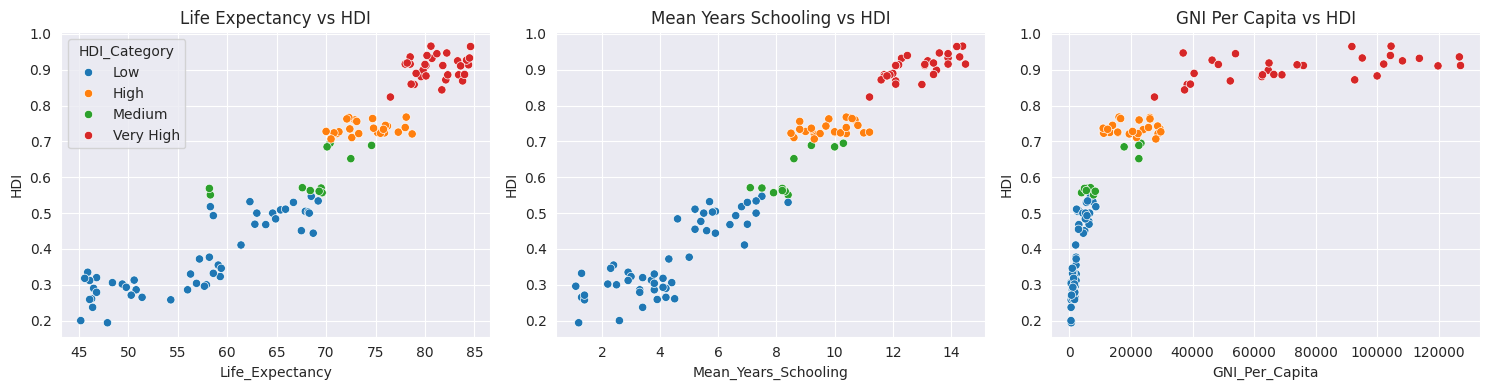

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.scatterplot(x='Life_Expectancy', y='HDI', data=df, ax=axes[0], hue='HDI_Category')
sns.scatterplot(x='Mean_Years_Schooling', y='HDI', data=df, ax=axes[1], hue='HDI_Category', legend=False)
sns.scatterplot(x='GNI_Per_Capita', y='HDI', data=df, ax=axes[2], hue='HDI_Category', legend=False)
axes[0].set_title('Life Expectancy vs HDI')
axes[1].set_title('Mean Years Schooling vs HDI')
axes[2].set_title('GNI Per Capita vs HDI')
plt.tight_layout()
plt.show()


## Epic 4: Data Preprocessing & Label Encoding

### Story 1 & 2: Select variables and handle missing values

In [10]:
df.isnull().sum()


Country                 0
Life_Expectancy         4
Mean_Years_Schooling    4
GNI_Per_Capita          4
Internet_Users          4
HDI                     0
HDI_Category            0
dtype: int64

In [11]:
numeric_features = ['Life_Expectancy','Mean_Years_Schooling','GNI_Per_Capita','Internet_Users']
for col in numeric_features:
    df[col] = df[col].fillna(df[col].mean())

df.isnull().sum()


Country                 0
Life_Expectancy         0
Mean_Years_Schooling    0
GNI_Per_Capita          0
Internet_Users          0
HDI                     0
HDI_Category            0
dtype: int64

### Story 3: Label Encoding for the `Country` column

In [12]:
le_country = LabelEncoder()
df['Country_Encoded'] = le_country.fit_transform(df['Country'])
df[['Country','Country_Encoded']].head()


,Country,Country_Encoded
0,Mali,67
1,Dominican Republic,30
2,Fiji,36
3,Zimbabwe,119
4,Kenya,59


### Story 4: Final feature/target selection

In [13]:
feature_cols = ['Life_Expectancy', 'Mean_Years_Schooling', 'GNI_Per_Capita', 'Internet_Users']
X = df[feature_cols]
y = df['HDI']
X.head()


,Life_Expectancy,Mean_Years_Schooling,GNI_Per_Capita,Internet_Users
0,46.8,3.4,1532.0,22.3
1,72.9,10.7,22642.0,83.0
2,72.5,8.6,22554.0,60.8
3,48.4,4.4,421.0,24.3
4,67.5,5.6,4960.0,23.0


## Epic 5: Dividing the Dataset into Train and Test Data (75/25 split)

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)
print("Train size:", X_train.shape, " Test size:", X_test.shape)


Train size: (90, 4)  Test size: (30, 4)


## Epic 6: Fitting the Model

### Story 1: Train the Linear Regression model

In [15]:
model = LinearRegression()
model.fit(X_train, y_train)

print("Intercept:", model.intercept_)
print("Coefficients:", dict(zip(feature_cols, model.coef_)))


Intercept: -0.10111205416759594
Coefficients: {'Life_Expectancy': np.float64(0.005479798323346634), 'Mean_Years_Schooling': np.float64(0.019312109093937917), 'GNI_Per_Capita': np.float64(3.0529876211891477e-07), 'Internet_Users': np.float64(0.0032276640762336157)}


### Story 2: Generate predictions

In [16]:
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

comparison = pd.DataFrame({'Actual': y_test.values, 'Predicted': y_pred_test.round(3)})
comparison.head(10)


,Actual,Predicted
0,0.745,0.783
1,0.468,0.491
2,0.451,0.453
3,0.304,0.329
4,0.721,0.725
5,0.728,0.714
6,0.444,0.467
7,0.330,0.457
8,0.312,0.255
9,0.484,0.476


### Story 3: Evaluate performance

In [17]:
train_r2 = r2_score(y_train, y_pred_train)
test_r2 = r2_score(y_test, y_pred_test)
mse = mean_squared_error(y_test, y_pred_test)
mae = mean_absolute_error(y_test, y_pred_test)

print(f"Train R2 Score : {train_r2:.4f}")
print(f"Test  R2 Score : {test_r2:.4f}")
print(f"Mean Squared Error : {mse:.5f}")
print(f"Mean Absolute Error: {mae:.5f}")


Train R2 Score : 0.9872
Test  R2 Score : 0.9788
Mean Squared Error : 0.00095
Mean Absolute Error: 0.02019


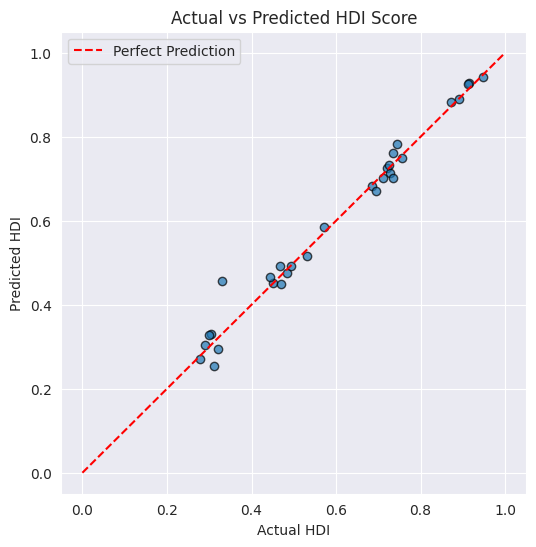

In [18]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_test, alpha=0.7, edgecolor='k')
plt.plot([0,1],[0,1],'r--', label='Perfect Prediction')
plt.xlabel('Actual HDI')
plt.ylabel('Predicted HDI')
plt.title('Actual vs Predicted HDI Score')
plt.legend()
plt.show()


### HDI Category classification helper

Once a numeric HDI score is predicted, it is mapped to a category using the
standard UNDP-style thresholds:

| HDI Score        | Category   |
|-------------------|-----------|
| >= 0.800          | Very High |
| 0.700 - 0.799     | High      |
| 0.550 - 0.699     | Medium    |
| < 0.550           | Low       |


In [19]:
def classify_hdi(score):
    if score >= 0.800:
        return "Very High"
    elif score >= 0.700:
        return "High"
    elif score >= 0.550:
        return "Medium"
    else:
        return "Low"

comparison['Predicted_Category'] = comparison['Predicted'].apply(classify_hdi)
comparison.head(10)


,Actual,Predicted,Predicted_Category
0,0.745,0.783,High
1,0.468,0.491,Low
2,0.451,0.453,Low
3,0.304,0.329,Low
4,0.721,0.725,High
5,0.728,0.714,High
6,0.444,0.467,Low
7,0.330,0.457,Low
8,0.312,0.255,Low
9,0.484,0.476,Low


## Epic 7: Saving the Model

The trained model is serialized with `pickle` so the Flask application can
load it without retraining.

In [20]:
with open('../Flask/HDI.pkl', 'wb') as f:
    pickle.dump({
        'model': model,
        'feature_cols': feature_cols,
        'countries': sorted(df['Country'].unique().tolist())
    }, f)

print("Model saved to ../Flask/HDI.pkl")


Model saved to ../Flask/HDI.pkl


## Summary

- Trained a **Linear Regression** model to predict the HDI score from
  Life Expectancy, Mean Years of Schooling, GNI Per Capita, and Internet Users.
- Achieved an R2 score reported above on the held-out test set.
- Saved the model (plus the list of countries used for the dropdown) to
  `Flask/HDI.pkl` for use in the Flask web application (see Epic 8).
